# Importing Libraries

In [29]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data

In [30]:
dataset= load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas() 

# Data Cleanup

In [31]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

# Filter for US Data Analyst Role

In [32]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [38]:
df_plot1 = df_DA_US['job_location'].value_counts().head(10).to_frame()


In [39]:
df_plot1

,count
job_location,
Anywhere,5106
"New York, NY",3035
"Atlanta, GA",2741
"Chicago, IL",2337
"Austin, TX",1919
"Dallas, TX",1862
"Washington, DC",1592
"Charlotte, NC",1433
"Tampa, FL",1431


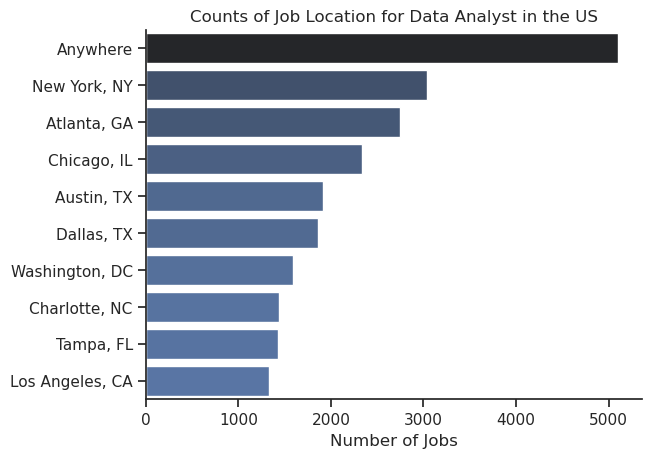

In [40]:
sns.set_theme(style='ticks')
sns.barplot(data=df_plot1,x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine() #to remove the border around the graph
#Better labels and titles
plt.title('Counts of Job Location for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

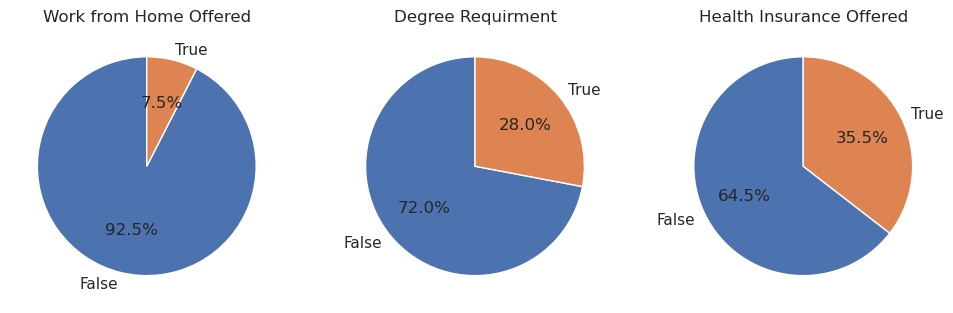

In [36]:

dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirment',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['False', 'True'])
    ax[i].set_title(title)


plt.show()

In [42]:
df_plot2 = df_DA_US['company_name'].value_counts().head(10).to_frame()

In [43]:
df_plot2

,count
company_name,
Robert Half,959
Insight Global,827
Dice,584
UnitedHealth Group,507
Get It Recruit - Information Technology,503
Citi,477
Corporate,416
SynergisticIT,374
Centene Corporation,350


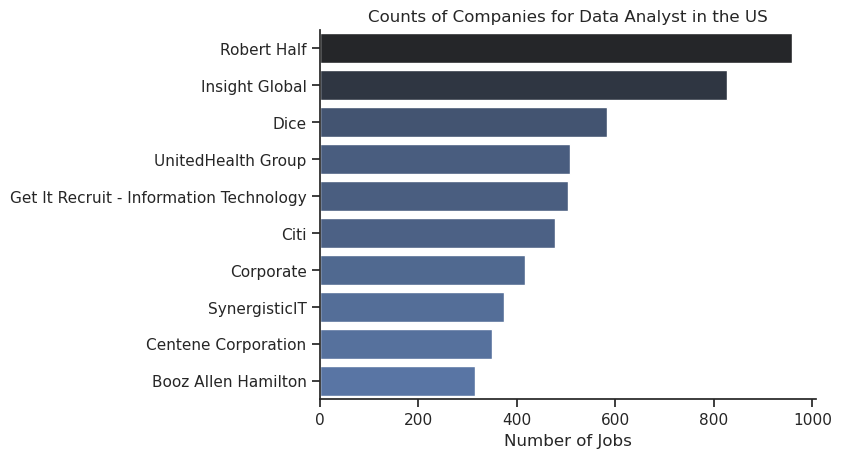

In [44]:
sns.set_theme(style='ticks')
sns.barplot(data=df_plot2,x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine() #to remove the border around the graph
#Better labels and titles
plt.title('Counts of Companies for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()